# Ancient Papyrus Daiqiry Data Extraction Script
This notebook is used to extract from .h5 file 1D serial XRD scan to .xy file for TOPAS software. The extraction is not one-click button. It is recommended that the user have a look first at the .h5 file architecture through Silx. Each cell of the notebook will allow the user to access the folder slowly, allowing the user to choose which folder, sample, dataset, scan number of interest. Inspection is possible at each step. 

## Notebook to Extract Processed 1D-XRD Scan

In [1]:
# load necessary packages
import numpy as np
import os
import h5py
from pathlib import Path
import matplotlib.pyplot as plt
import glob

We start with parent folder PROCESSED_DATA. First, have a look at all the sample folder we have here and choose which one you would like to proceed. 

In [2]:
# define parent folder file
folderpath = "/data/visitor/ihhg69/id13/20260409/PROCESSED_DATA/"
folder = Path(folderpath)
for f in folder.iterdir():
    print(f.name)

dq_pap163
dq_pap217
workflows
pap163
pap217
dq_modernpap
__CALIB
dq_al2o3
siemens
modernpap
al2o3


Here, folders with "dq_xxx" is acquisited using daiquiri user interface and folders without "dq_xxx" is tested measurements (for radiation damage eg) using BLISS cmd. <br>
Choose your interest sample folder below (just copy and paste)

In [3]:
sample_folder_name = "dq_pap217"
sample_folder = os.path.join(folderpath,sample_folder_name)
for f in Path(sample_folder).iterdir():
    print(f.name)

dq_pap217_roi146602_164526
dq_pap217_roi146601_164525
dq_pap217_roi146599_164523
dq_pap217_roi146600_164524
dq_pap217_roi146603_164528
dq_pap217_roi146597_164520
dq_pap217_roi146598_164522
dq_pap217_roi146596_164519


In [4]:
twotheta_path = f"/1.1/eiger_average/average/2th"
intensity_path = f"/1.1/eiger_average/average/average_intensity"

parent_folder = r"/home/esrf/tran/extracted_data"
saving_address = os.path.join(parent_folder, sample_folder_name)
print(saving_address)
os.makedirs(saving_address, exist_ok = True)

/home/esrf/tran/extracted_data/dq_pap217


dq_pap217_roi146602_164526
----
dq_pap217_roi146601_164525
----
dq_pap217_roi146599_164523
----
dq_pap217_roi146600_164524
----
dq_pap217_roi146603_164528
----
dq_pap217_roi146597_164520
----
dq_pap217_roi146598_164522
----
dq_pap217_roi146596_164519
----


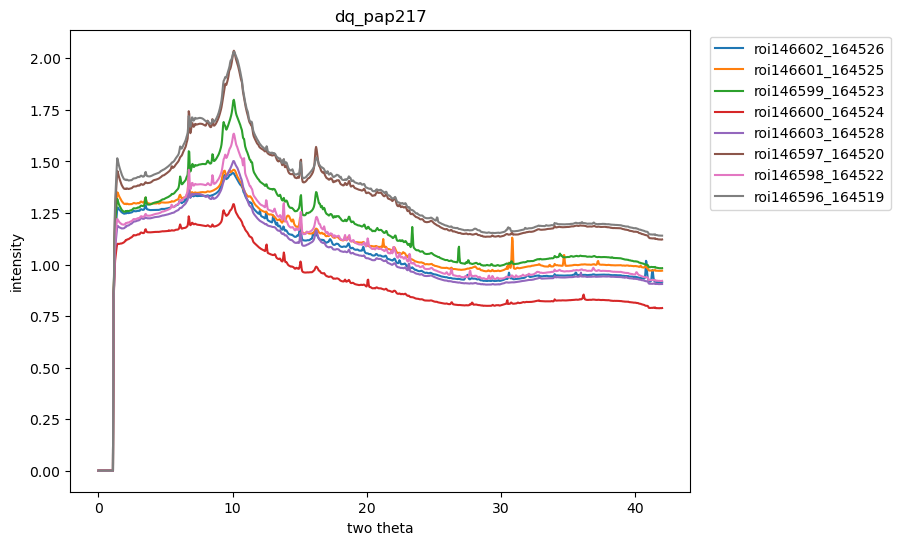

In [5]:
plt.figure(figsize=(8, 6))

for f in Path(sample_folder).iterdir():
    if f.is_dir():
        print(f.name)
        dataset_folder = os.path.join(sample_folder, f.name)
        scan_path = os.path.join(dataset_folder, f.name + ".h5")

        if not os.path.isfile(scan_path):
            print("no .h5 file, skipped")
            print("----")
            continue

        #print(scan_path)
        with h5py.File(scan_path, "r") as s:
            x = s[twotheta_path][:]
            y = s[intensity_path][:]

        plt.plot(x, np.sqrt(y), label="_".join(f.name.split("_")[-2:]))

        xy = np.column_stack((x, y))
        filename = f"{f.name}.xy"
        savepath = os.path.join(saving_address, filename)
        np.savetxt(savepath, xy)

        print("----")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xlabel('two theta')
plt.ylabel('intensity')
plt.title(sample_folder_name)
plt.show()

In [6]:
xy_files = sorted(glob.glob(os.path.join(saving_address, "*.xy")))

all_y = []
x_ref = None

for file in xy_files:
    data = np.loadtxt(file)
    x = data[:, 0]
    y = data[:, 1]

    if x_ref is None:
        x_ref = x
    elif not np.allclose(x, x_ref):
        print(f"Skipped (x mismatch): {os.path.basename(file)}")
        continue

    all_y.append(y)

all_y = np.array(all_y)

y_avg = np.mean(all_y, axis=0)

avg_xy = np.column_stack((x_ref, y_avg))

np.savetxt(os.path.join(saving_address, f"{sample_folder_name}_avg.xy"), avg_xy)

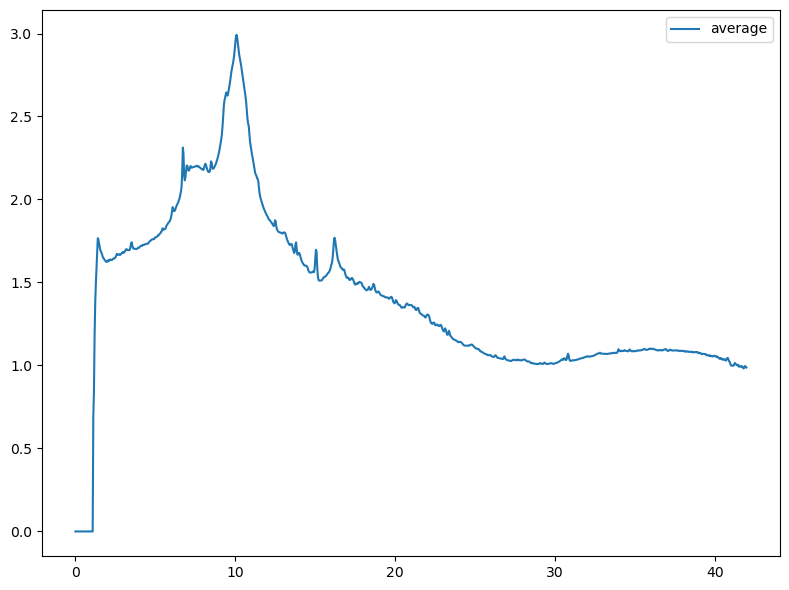

In [7]:
plt.figure(figsize=(8,6))
plt.plot(x_ref, y_avg, label="average")
plt.legend()
plt.tight_layout()
plt.show()